## 📊 Global Sales Data - Data Visualization & Analysis Project

**Dataset:** ExcelBI 1M Sales Records  
**Records Analysed:** 1,000,000  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Total Visualisations:** 22 charts across 14 sections

---

### Dataset Fields
`Region` `Country` `Item Type` `Sales Channel` `Order Priority`  
`Order Date` `Ship Date` `Units Sold` `Unit Price` `Unit Cost`  
`Total Revenue` `Total Cost` `Total Profit`

---

### 📋 Sections Covered

| # | Section | What It Covers |
|---|---------|----------------|
| 1–3 | **Setup & Data Prep** | Imports, loading CSV, cleaning dates, new columns |
| 4 | **Descriptive Statistics** | .describe(), KPI summary — Revenue, Profit, Units |
| 5 | **Regional Analysis** | Revenue & Profit by Region, Top 15 Countries |
| 6 | **Item Type Analysis** | Profit, Margin %, Revenue share by product |
| 7 | **Time Series Analysis** | Yearly trend, Monthly heatmap, Day of week, Quarterly |
| 8 | **Sales Channel Analysis** | Online vs Offline — revenue, profit, donut charts |
| 9 | **Order Priority Analysis** | Critical/High/Medium/Low — orders & ship days |
| 10 | **Profit & Cost Analysis** | Scatter, histogram, box plot, violin chart |
| 11 | **Shipping Analysis** | Avg ship days by region, duration distribution |
| 12 | **Correlation & Heatmaps** | Correlation matrix, Item × Region pivot heatmap |
| 13 | **Rankings Analysis** | Top 5 / Bottom 5 countries, most sold items |
| 14 | **Final Summary** | KPI auto-print, best region/item/country |

## 📦 SECTION 1 - IMPORTS & SETUP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 📥 SECTION 2 - LOAD DATA

In [2]:
# Load the dataset — update filename if needed
df = pd.read_csv('data.csv')

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 1,000,000 rows × 14 columns


,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Sub-Saharan Africa,South Africa,Fruits,Offline,M,7/27/2012,443368995,7/28/2012,1593,9.33,6.92,14862.69,11023.56,3839.13
1,Middle East and North Africa,Morocco,Clothes,Online,M,9/14/2013,667593514,10/19/2013,4611,109.28,35.84,503890.08,165258.24,338631.84
2,Australia and Oceania,Papua New Guinea,Meat,Offline,M,5/15/2015,940995585,6/4/2015,360,421.89,364.69,151880.40,131288.40,20592.00
3,Sub-Saharan Africa,Djibouti,Clothes,Offline,H,5/17/2017,880811536,7/2/2017,562,109.28,35.84,61415.36,20142.08,41273.28
4,Europe,Slovakia,Beverages,Offline,L,10/26/2016,174590194,12/4/2016,3973,47.45,31.79,188518.85,126301.67,62217.18


## 🧹 SECTION 3 - DATA CLEANING

In [3]:
# 3.1 Check data types
print('=== DATA TYPES ===')
print(df.dtypes)

# 3.2 Missing values
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())

=== DATA TYPES ===
Region                str
Country               str
Item Type             str
Sales Channel         str
Order Priority        str
Order Date            str
Order ID            int64
Ship Date             str
Units Sold          int64
Unit Price        float64
Unit Cost         float64
Total Revenue     float64
Total Cost        float64
Total Profit      float64
dtype: object

=== MISSING VALUES ===
Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64


In [4]:
# 3.3 Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# 3.4 Extract time features
df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order Day']     = df['Order Date'].dt.day_name()

# 3.5 Shipping duration (days)
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# 3.6 Profit Margin %
df['Profit Margin %'] = (df['Total Profit'] / df['Total Revenue'] * 100).round(2)

# 3.7 Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df):,}')

print('\n✅ Cleaning done. New shape:', df.shape)
df.head(3)

Duplicates removed: 50,009

✅ Cleaning done. New shape: (949991, 21)


,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,...,Total Revenue,Total Cost,Total Profit,Order Year,Order Month,Order Month Name,Order Quarter,Order Day,Ship Days,Profit Margin %
0,Sub-Saharan Africa,South Africa,Fruits,Offline,M,2012-07-27,443368995,2012-07-28,1593,9.33,...,14862.69,11023.56,3839.13,2012,7,Jul,3,Friday,1,25.83
1,Middle East and North Africa,Morocco,Clothes,Online,M,2013-09-14,667593514,2013-10-19,4611,109.28,...,503890.08,165258.24,338631.84,2013,9,Sep,3,Saturday,35,67.20
2,Australia and Oceania,Papua New Guinea,Meat,Offline,M,2015-05-15,940995585,2015-06-04,360,421.89,...,151880.40,131288.40,20592.00,2015,5,May,2,Friday,20,13.56


## 🔍 SECTION 4 - DESCRIPTIVE STATISTICS

In [5]:
# 4.1 Full statistical summary
df[['Units Sold','Unit Price','Unit Cost',
    'Total Revenue','Total Cost','Total Profit',
    'Profit Margin %','Ship Days']].describe().round(2)

,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Profit Margin %,Ship Days
count,949991.00,949991.00,949991.00,949991.00,949991.00,949991.00,949991.00,949991.00
mean,4999.04,266.00,187.50,1329457.69,937174.99,392282.70,34.33,25.02
std,2885.53,216.96,175.63,1468398.65,1148812.20,378834.37,13.15,14.72
min,1.00,9.33,6.92,9.33,6.92,2.41,13.56,0.00
25%,2502.00,81.73,35.84,277677.40,161684.62,95057.07,25.83,12.00
50%,4997.00,154.06,97.44,784774.00,466917.57,281128.32,33.00,25.00
75%,7497.00,421.89,263.33,1822334.30,1196606.52,565364.80,39.77,38.00
max,10000.00,668.27,524.96,6682700.00,5249600.00,1738700.00,67.20,50.00


In [6]:
# 4.2 Key KPIs
total_revenue = df['Total Revenue'].sum()
total_profit  = df['Total Profit'].sum()
total_cost    = df['Total Cost'].sum()
total_units   = df['Units Sold'].sum()
avg_margin    = df['Profit Margin %'].mean()
avg_ship_days = df['Ship Days'].mean()

print('='*45)
print(f'  💰 Total Revenue    : ${total_revenue:>15,.2f}')
print(f'  💸 Total Cost       : ${total_cost:>15,.2f}')
print(f'  📈 Total Profit     : ${total_profit:>15,.2f}')
print(f'  📦 Total Units Sold : {total_units:>16,}')
print(f'  📊 Avg Profit Margin: {avg_margin:>14.2f}%')
print(f'  🚚 Avg Ship Days    : {avg_ship_days:>14.1f}')
print('='*45)

  💰 Total Revenue    : $1,262,972,839,116.55
  💸 Total Cost       : $890,307,805,124.68
  📈 Total Profit     : $372,665,033,991.87
  📦 Total Units Sold :    4,749,043,128
  📊 Avg Profit Margin:          34.33%
  🚚 Avg Ship Days    :           25.0


## 📊 SECTION 5 - REGIONAL ANALYSIS

In [7]:
# 5.1 Revenue & Profit by Region
region_stats = df.groupby('Region').agg(
    Total_Revenue = ('Total Revenue','sum'),
    Total_Profit  = ('Total Profit','sum'),
    Total_Orders  = ('Order ID','count'),
    Avg_Margin    = ('Profit Margin %','mean')
).sort_values('Total_Revenue', ascending=False).round(2)

print(region_stats.to_string())

                                   Total_Revenue  Total_Profit  Total_Orders  Avg_Margin
Region                                                                                  
Sub-Saharan Africa                  3.285738e+11  9.701140e+10        246924       34.35
Europe                              3.265917e+11  9.634690e+10        246135       34.34
Asia                                1.842248e+11  5.431502e+10        138769       34.31
Middle East and North Africa        1.569990e+11  4.631294e+10        118103       34.32
Central America and the Caribbean   1.366260e+11  4.033895e+10        102631       34.30
Australia and Oceania               1.023990e+11  3.023670e+10         76773       34.29
North America                       2.755838e+10  8.103122e+09         20656       34.25


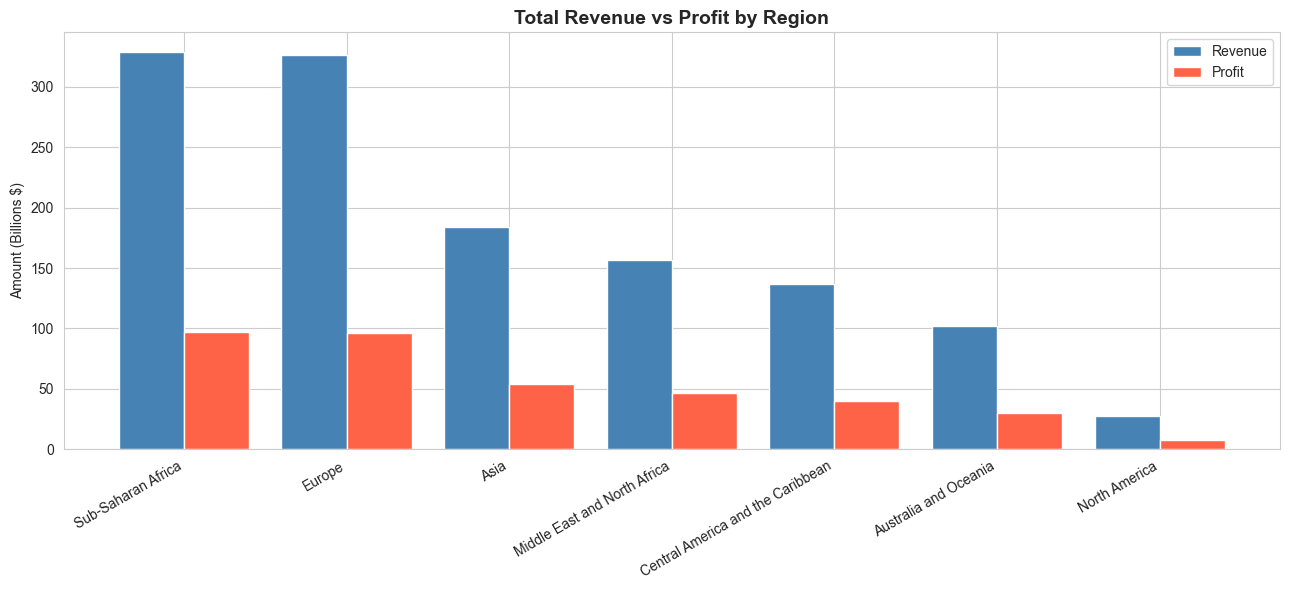

In [8]:
# 5.2 Chart: Revenue & Profit by Region (grouped bar)
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(region_stats))
w = 0.4
ax.bar(x - w/2, region_stats['Total_Revenue']/1e9, w, label='Revenue', color='steelblue')
ax.bar(x + w/2, region_stats['Total_Profit']/1e9,  w, label='Profit',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(region_stats.index, rotation=30, ha='right')
ax.set_ylabel('Amount (Billions $)')
ax.set_title('Total Revenue vs Profit by Region', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('01_region_revenue_profit.png', dpi=150)
plt.show()

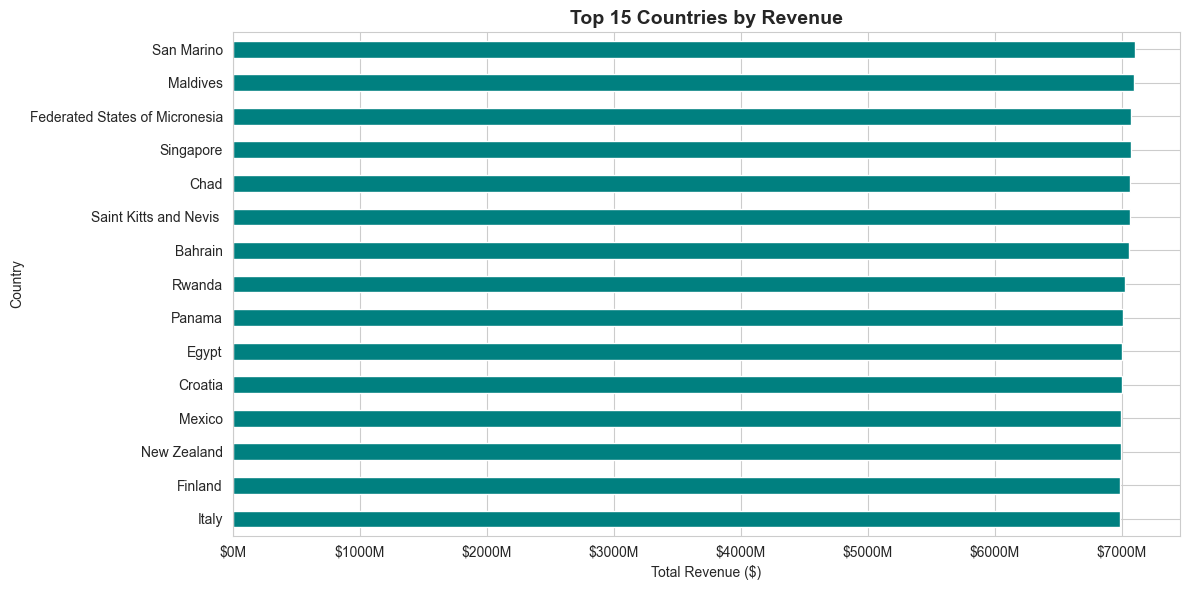

In [9]:
# 5.3 Top 15 Countries by Revenue
top_countries = df.groupby('Country')['Total Revenue'].sum()\
                  .sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_countries.plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('Total Revenue ($)')
ax.set_title('Top 15 Countries by Revenue', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.savefig('02_top_countries_revenue.png', dpi=150)
plt.show()

## 🛒 SECTION 6 - ITEM TYPE ANALYSIS

In [10]:
# 6.1 Item Type performance summary
item_stats = df.groupby('Item Type').agg(
    Orders        = ('Order ID','count'),
    Units_Sold    = ('Units Sold','sum'),
    Total_Revenue = ('Total Revenue','sum'),
    Total_Profit  = ('Total Profit','sum'),
    Avg_Margin    = ('Profit Margin %','mean')
).sort_values('Total_Profit', ascending=False).round(2)

print(item_stats.to_string())

                 Orders  Units_Sold  Total_Revenue  Total_Profit  Avg_Margin
Item Type                                                                   
Cosmetics         79282   395693036   1.729970e+11  6.879915e+10       39.77
Household         79080   395947425   2.645998e+11  6.562037e+10       24.80
Office Supplies   78988   394428880   2.568560e+11  4.979665e+10       19.39
Baby Food         79312   396287084   1.011642e+11  3.798808e+10       37.55
Cereal            79062   394763608   8.120287e+10  3.497211e+10       43.07
Clothes           79040   395675847   4.323946e+10  2.905843e+10       67.20
Vegetables        78968   393165441   6.057107e+10  2.482053e+10       40.98
Meat              79090   395470437   1.668450e+11  2.262091e+10       13.56
Snacks            79220   396492511   6.049683e+10  2.186260e+10       36.14
Personal Care     79352   397207048   3.246373e+10  9.954009e+09       30.66
Beverages         79130   396896184   1.883272e+10  6.215394e+09       33.00

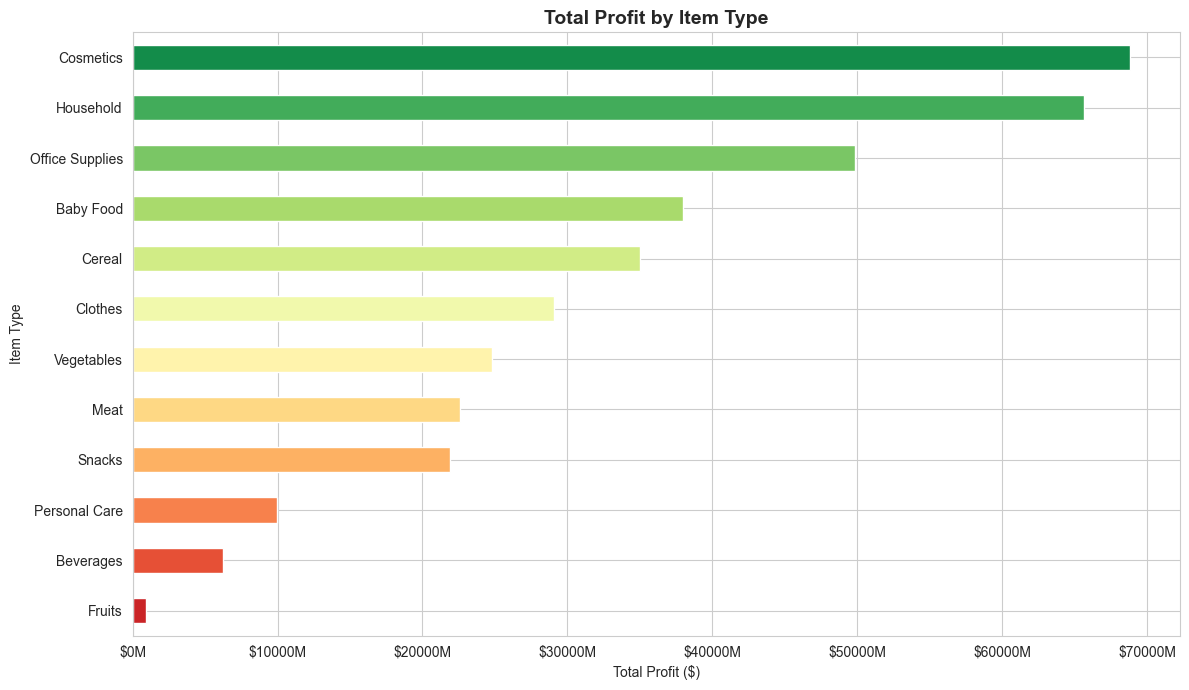

In [11]:
# 6.2 Chart: Profit by Item Type (horizontal bar)
fig, ax = plt.subplots(figsize=(12, 7))
item_stats['Total_Profit'].sort_values().plot(kind='barh', ax=ax,
    color=sns.color_palette('RdYlGn', len(item_stats)))
ax.set_xlabel('Total Profit ($)')
ax.set_title('Total Profit by Item Type', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.savefig('03_item_type_profit.png', dpi=150)
plt.show()

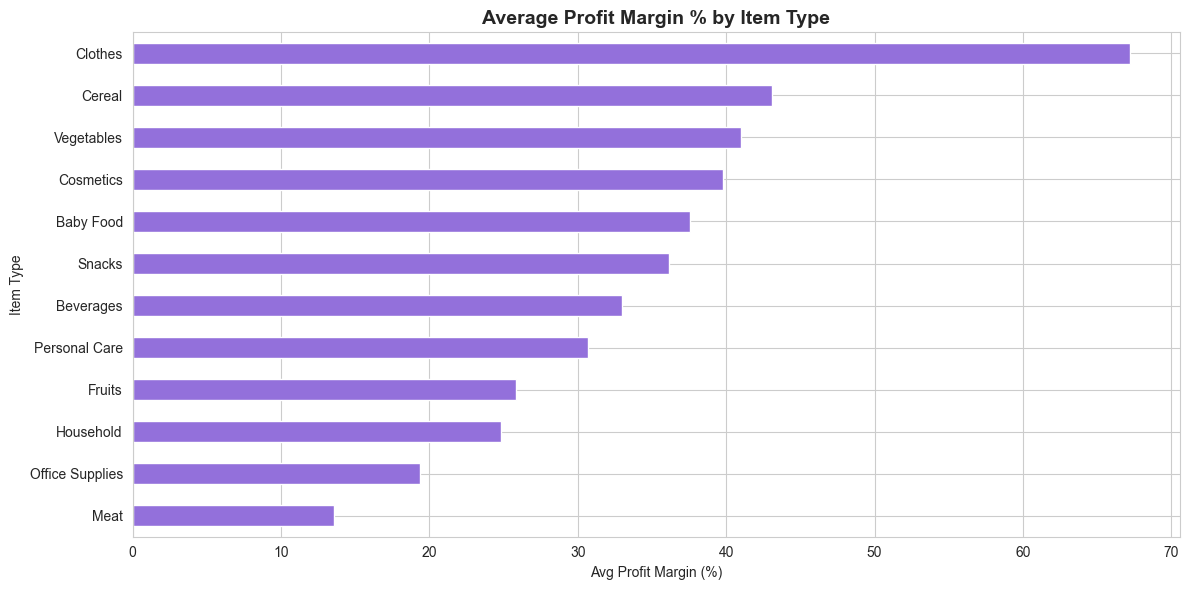

In [12]:
# 6.3 Chart: Average Profit Margin % by Item Type
fig, ax = plt.subplots(figsize=(12, 6))
item_stats['Avg_Margin'].sort_values().plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_xlabel('Avg Profit Margin (%)')
ax.set_title('Average Profit Margin % by Item Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_item_margin.png', dpi=150)
plt.show()

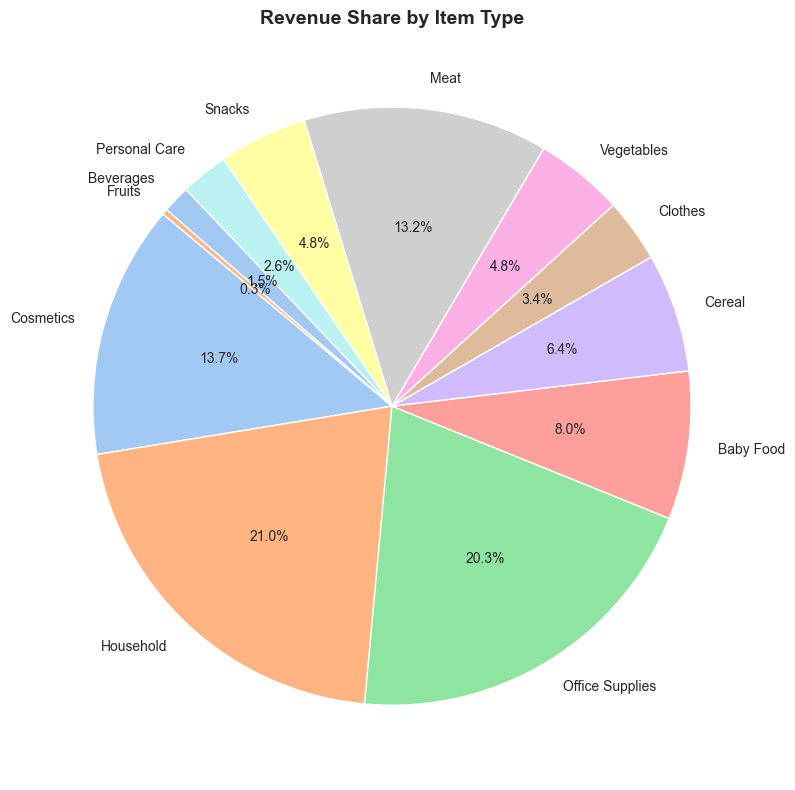

In [13]:
# 6.4 Pie Chart: Revenue share by Item Type
fig, ax = plt.subplots(figsize=(10, 8))
item_stats['Total_Revenue'].plot(kind='pie', ax=ax,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('pastel', len(item_stats)))
ax.set_ylabel('')
ax.set_title('Revenue Share by Item Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_item_revenue_pie.png', dpi=150)
plt.show()

## 📅 SECTION 7 - TIME SERIES ANALYSIS

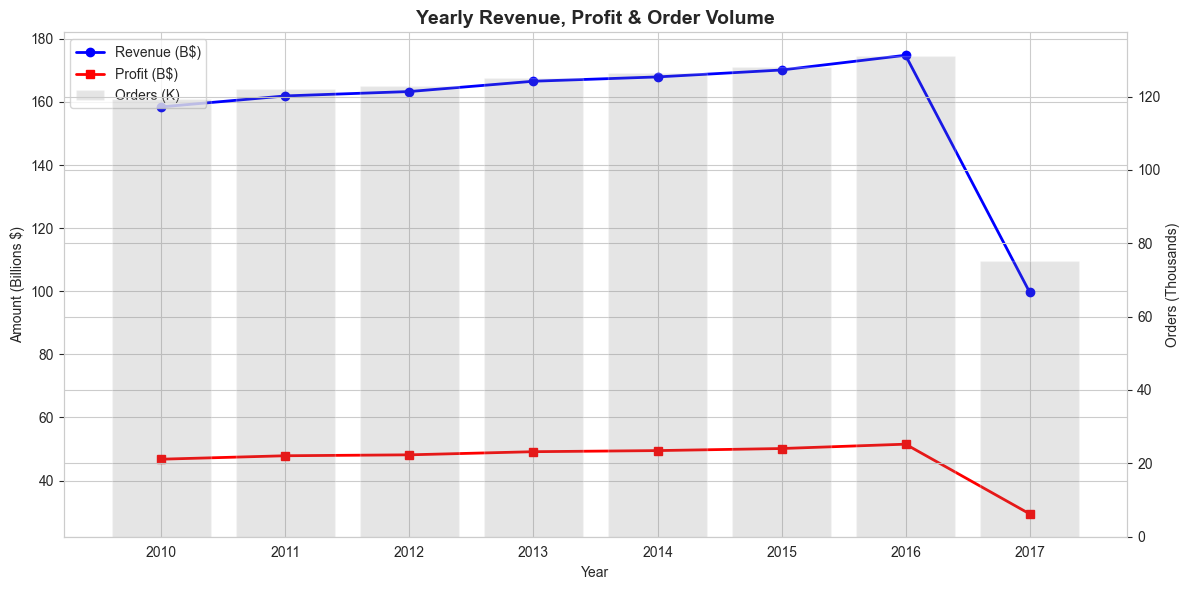

In [14]:
# 7.1 Yearly Revenue & Profit Trend
yearly = df.groupby('Order Year').agg(
    Revenue = ('Total Revenue','sum'),
    Profit  = ('Total Profit','sum'),
    Orders  = ('Order ID','count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(yearly['Order Year'], yearly['Revenue']/1e9, 'b-o', label='Revenue (B$)', lw=2)
ax1.plot(yearly['Order Year'], yearly['Profit']/1e9,  'r-s', label='Profit (B$)',  lw=2)
ax2.bar(yearly['Order Year'], yearly['Orders']/1e3, alpha=0.2, color='gray', label='Orders (K)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Amount (Billions $)')
ax2.set_ylabel('Orders (Thousands)')
ax1.set_title('Yearly Revenue, Profit & Order Volume', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig('06_yearly_trend.png', dpi=150)
plt.show()

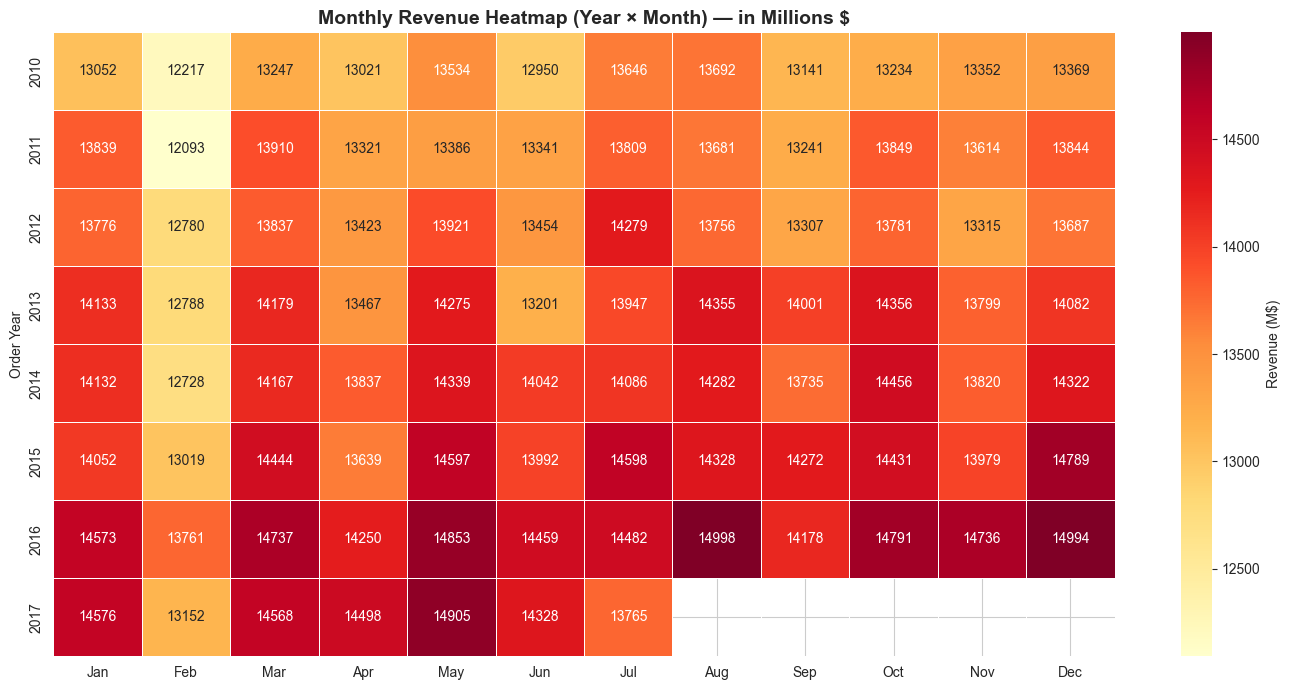

In [15]:
# 7.2 Monthly Revenue Heatmap (Year × Month)
pivot_monthly = df.pivot_table(
    values='Total Revenue', index='Order Year',
    columns='Order Month', aggfunc='sum'
) / 1e6  # in millions

pivot_monthly.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot_monthly, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Revenue (M$)'})
ax.set_title('Monthly Revenue Heatmap (Year × Month) — in Millions $',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_monthly_heatmap.png', dpi=150)
plt.show()

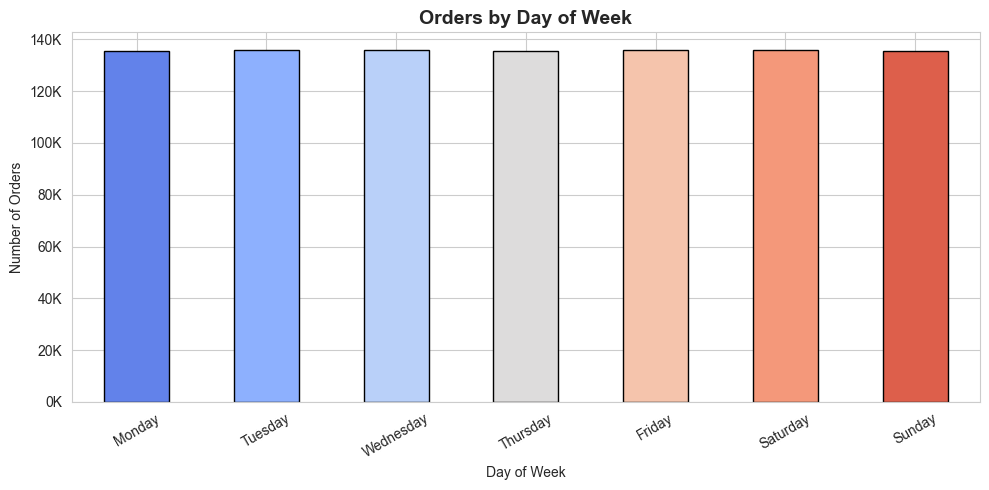

In [16]:
# 7.3 Orders by Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
orders_by_day = df['Order Day'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
orders_by_day.plot(kind='bar', ax=ax,
    color=sns.color_palette('coolwarm', 7), edgecolor='black')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Orders')
ax.set_title('Orders by Day of Week', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('08_orders_by_day.png', dpi=150)
plt.show()

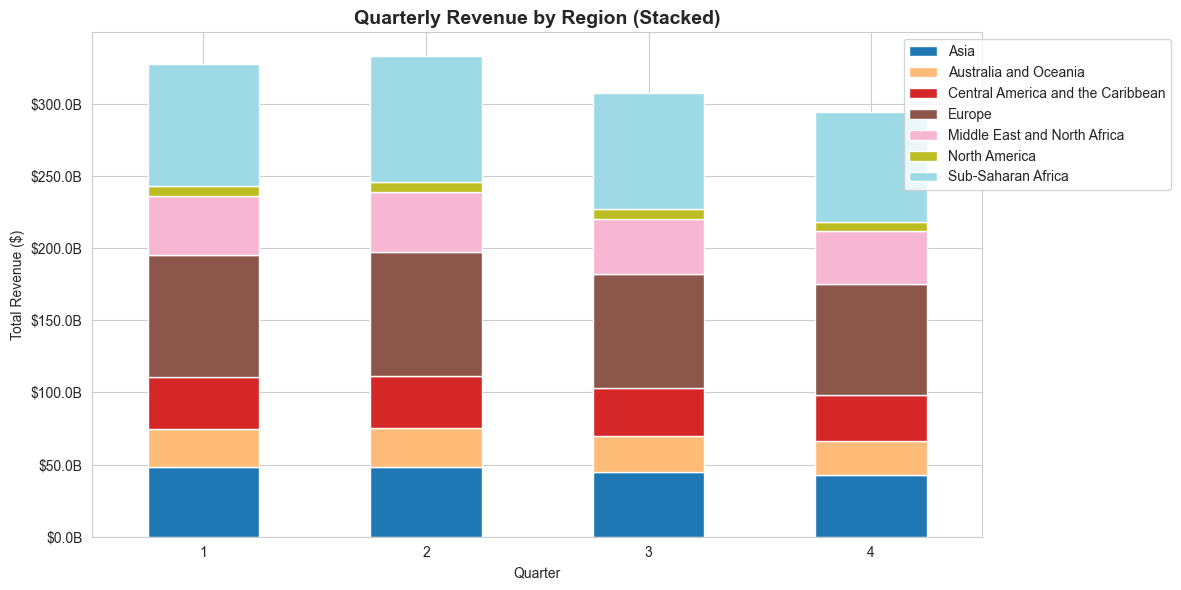

In [17]:
# 7.4 Quarterly Revenue by Region (stacked bar)
q_region = df.groupby(['Order Quarter','Region'])['Total Revenue'].sum().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
q_region.plot(kind='bar', stacked=True, ax=ax,
    colormap='tab20', edgecolor='white')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Revenue ($)')
ax.set_title('Quarterly Revenue by Region (Stacked)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e9:.1f}B'))
ax.legend(loc='upper right', bbox_to_anchor=(1.22, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('09_quarterly_region_stacked.png', dpi=150)
plt.show()

## 🏪 SECTION 8 — SALES CHANNEL ANALYSIS

In [18]:
# 8.1 Online vs Offline breakdown
channel = df.groupby('Sales Channel').agg(
    Orders        = ('Order ID','count'),
    Units_Sold    = ('Units Sold','sum'),
    Total_Revenue = ('Total Revenue','sum'),
    Total_Profit  = ('Total Profit','sum'),
    Avg_Margin    = ('Profit Margin %','mean')
).round(2)

print(channel)

               Orders  Units_Sold  Total_Revenue  Total_Profit  Avg_Margin
Sales Channel                                                             
Offline        475201  2375870807   6.318761e+11  1.864752e+11       34.33
Online         474790  2373172321   6.310968e+11  1.861899e+11       34.32


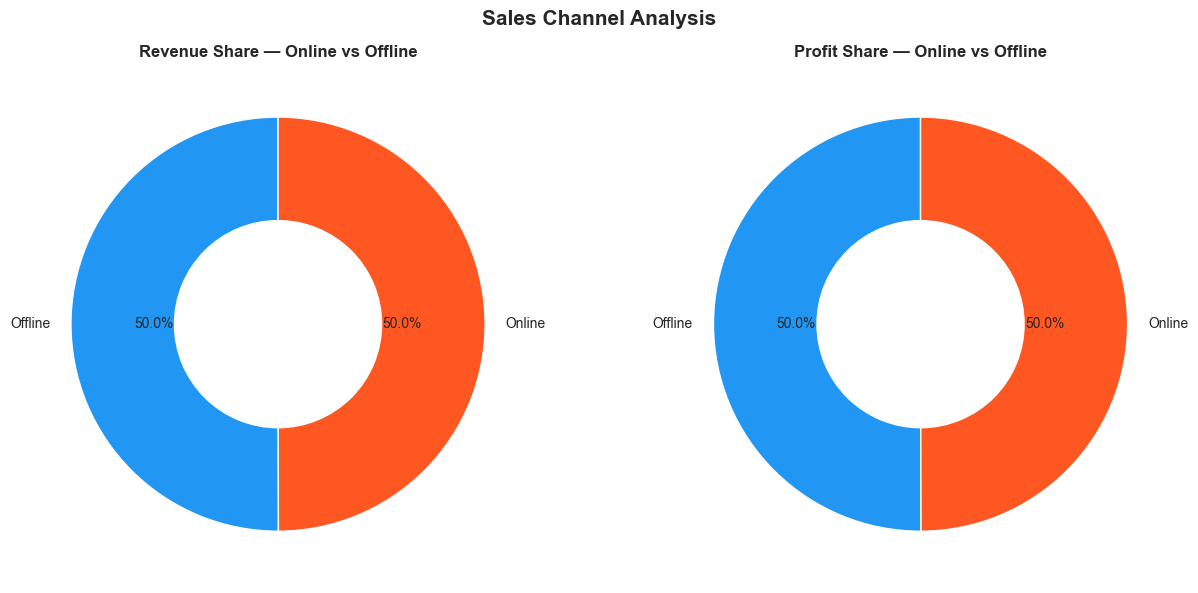

In [19]:
# 8.2 Chart: Sales Channel comparison (donut)
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, col, title in zip(axes,
    ['Total_Revenue','Total_Profit'],
    ['Revenue Share','Profit Share']):
    wedges, texts, autotexts = ax.pie(
        channel[col], labels=channel.index,
        autopct='%1.1f%%', startangle=90,
        colors=['#2196F3','#FF5722'],
        wedgeprops=dict(width=0.5)  # donut
    )
    ax.set_title(f'{title} — Online vs Offline', fontweight='bold')

plt.suptitle('Sales Channel Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('10_channel_donut.png', dpi=150)
plt.show()

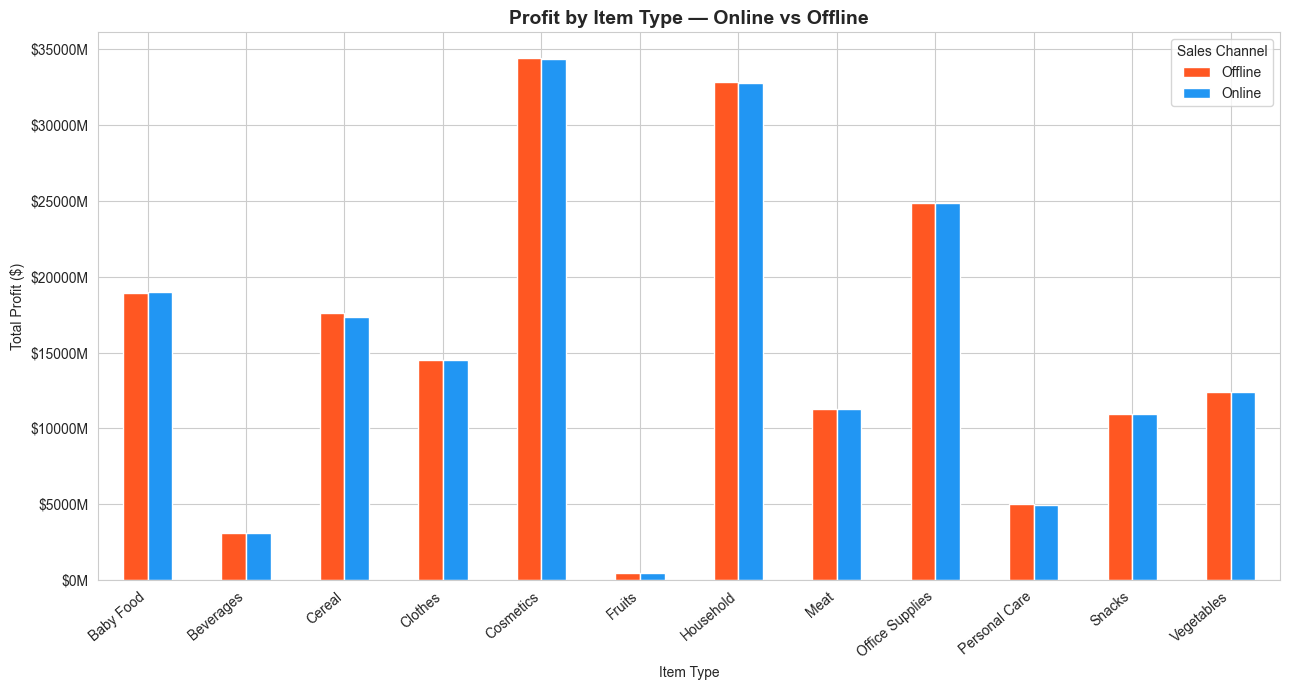

In [20]:
# 8.3 Channel performance by Item Type
ch_item = df.groupby(['Sales Channel','Item Type'])['Total Profit'].sum().unstack('Sales Channel')

fig, ax = plt.subplots(figsize=(13, 7))
ch_item.plot(kind='bar', ax=ax, color=['#FF5722','#2196F3'])
ax.set_xlabel('Item Type')
ax.set_ylabel('Total Profit ($)')
ax.set_title('Profit by Item Type — Online vs Offline', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('11_channel_item_profit.png', dpi=150)
plt.show()

## 🚨 SECTION 9 - ORDER PRIORITY ANALYSIS

In [21]:
# 9.1 Priority summary
priority_order = ['Critical','High','Medium','Low']
priority = df.groupby('Order Priority').agg(
    Orders     = ('Order ID','count'),
    Revenue    = ('Total Revenue','sum'),
    Profit     = ('Total Profit','sum'),
    Avg_Ship_Days = ('Ship Days','mean')
).reindex(priority_order).round(2)

print(priority)

                Orders  Revenue  Profit  Avg_Ship_Days
Order Priority                                        
Critical           NaN      NaN     NaN            NaN
High               NaN      NaN     NaN            NaN
Medium             NaN      NaN     NaN            NaN
Low                NaN      NaN     NaN            NaN


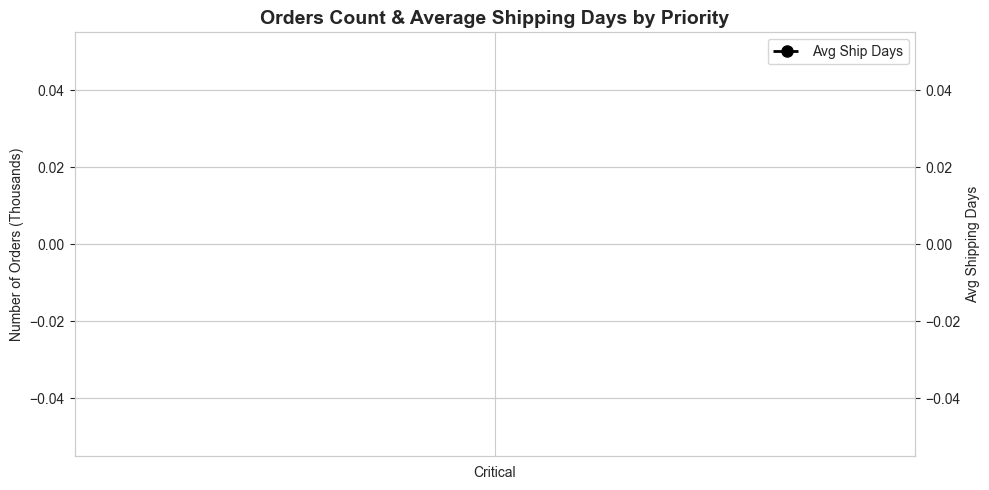

In [22]:
# 9.2 Chart: Orders & Avg Ship Days by Priority
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

colors = ['#d32f2f','#f57c00','#388e3c','#1976d2']
bars = ax1.bar(priority.index, priority['Orders']/1e3, color=colors, alpha=0.8)
line = ax2.plot(priority.index, priority['Avg_Ship_Days'], 'ko--',
                lw=2, ms=8, label='Avg Ship Days')

ax1.set_ylabel('Number of Orders (Thousands)')
ax2.set_ylabel('Avg Shipping Days')
ax1.set_title('Orders Count & Average Shipping Days by Priority',
              fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('12_priority_orders_ship.png', dpi=150)
plt.show()

## 💹 SECTION 10 - PROFIT & COST ANALYSIS

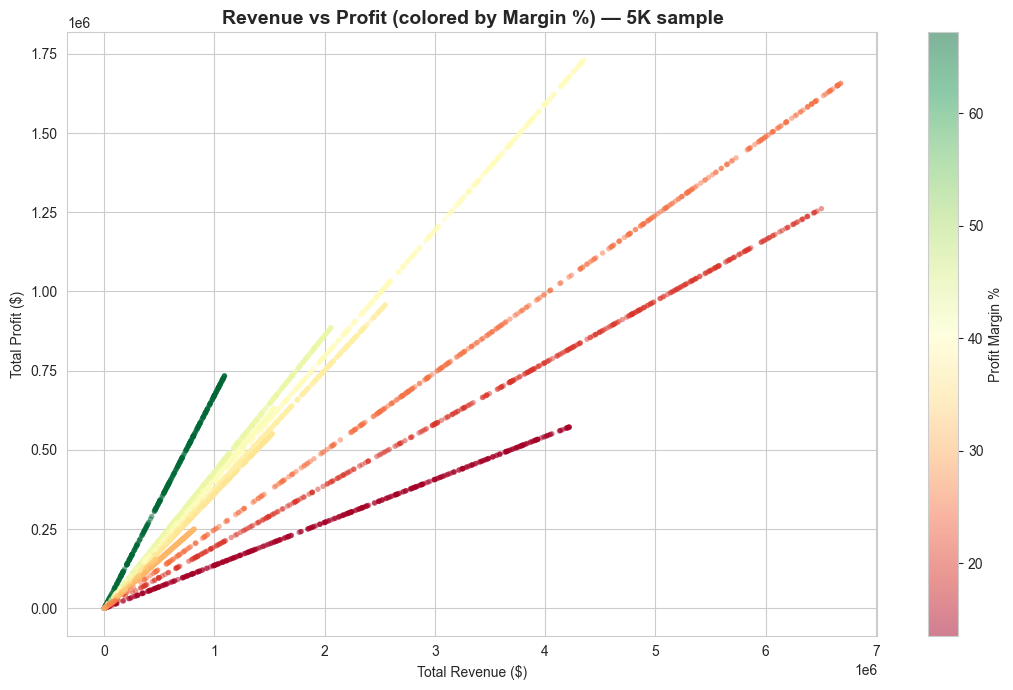

In [23]:
# 10.1 Scatter: Revenue vs Profit (sampled for speed)
sample = df.sample(n=5000, random_state=42)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    sample['Total Revenue'], sample['Total Profit'],
    c=sample['Profit Margin %'], cmap='RdYlGn',
    alpha=0.5, s=15, edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Profit Margin %')
ax.set_xlabel('Total Revenue ($)')
ax.set_ylabel('Total Profit ($)')
ax.set_title('Revenue vs Profit (colored by Margin %) — 5K sample',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('13_revenue_vs_profit_scatter.png', dpi=150)
plt.show()

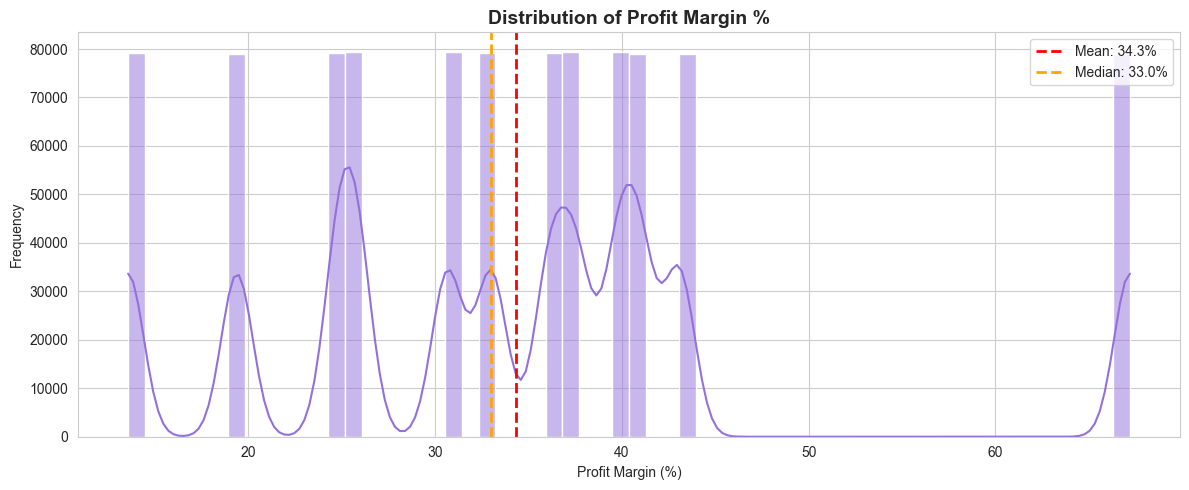

In [24]:
# 10.2 Distribution of Profit Margin % (histogram + KDE)
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df['Profit Margin %'], bins=60, kde=True,
             color='mediumpurple', ax=ax)
ax.axvline(df['Profit Margin %'].mean(), color='red',
           linestyle='--', lw=2, label=f"Mean: {df['Profit Margin %'].mean():.1f}%")
ax.axvline(df['Profit Margin %'].median(), color='orange',
           linestyle='--', lw=2, label=f"Median: {df['Profit Margin %'].median():.1f}%")
ax.set_xlabel('Profit Margin (%)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Profit Margin %', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('14_margin_distribution.png', dpi=150)
plt.show()

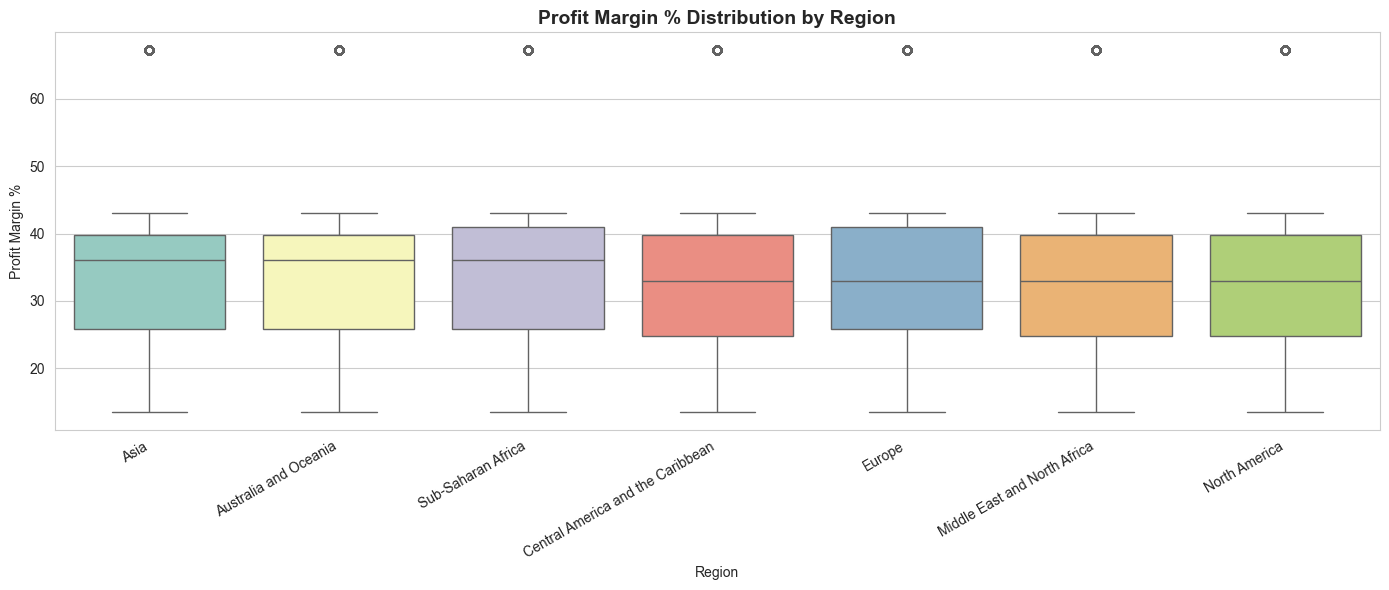

In [25]:
# 10.3 Box Plot: Profit Margin by Region
fig, ax = plt.subplots(figsize=(14, 6))
region_order = df.groupby('Region')['Profit Margin %'].median()\
                 .sort_values(ascending=False).index

sns.boxplot(data=df, x='Region', y='Profit Margin %',
            order=region_order, palette='Set3', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title('Profit Margin % Distribution by Region',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('15_margin_boxplot_region.png', dpi=150)
plt.show()

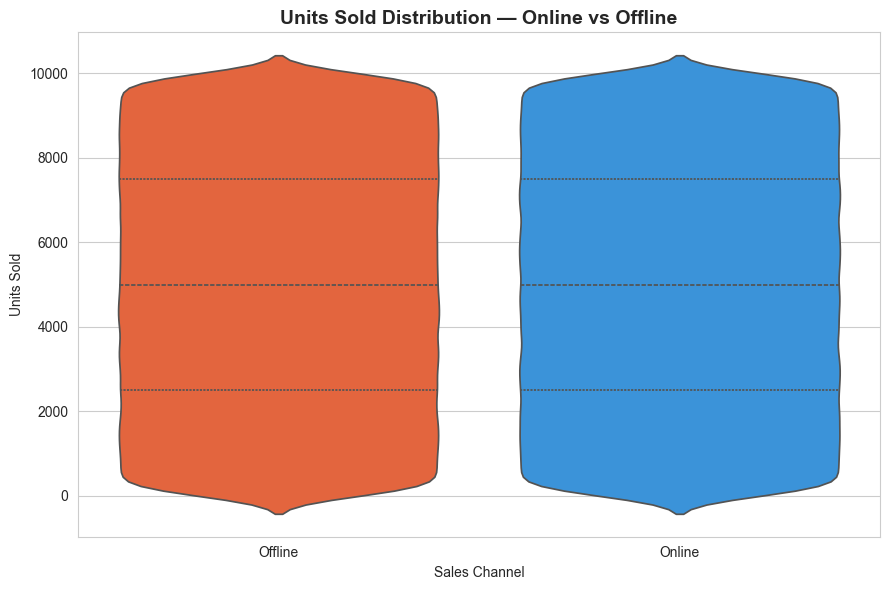

In [26]:
# 10.4 Violin Plot: Units Sold by Sales Channel
fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(data=df, x='Sales Channel', y='Units Sold',
               palette=['#FF5722','#2196F3'], inner='quartile', ax=ax)
ax.set_title('Units Sold Distribution — Online vs Offline',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('16_units_violin.png', dpi=150)
plt.show()

## 🚚 SECTION 11 — SHIPPING ANALYSIS

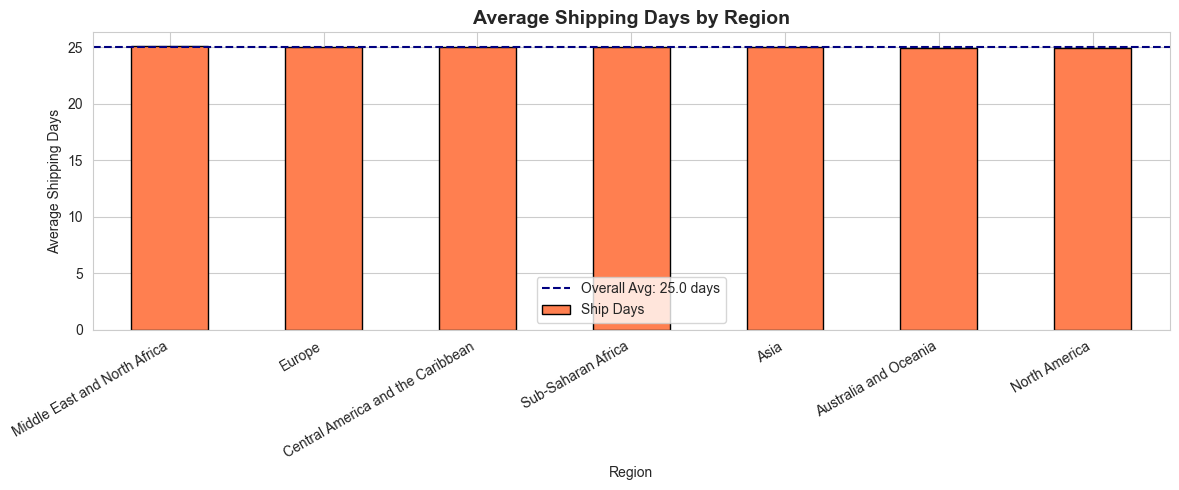

In [27]:
# 11.1 Avg Ship Days by Region
ship_region = df.groupby('Region')['Ship Days'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ship_region.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_ylabel('Average Shipping Days')
ax.set_title('Average Shipping Days by Region', fontsize=14, fontweight='bold')
ax.axhline(ship_region.mean(), color='navy', linestyle='--',
           label=f'Overall Avg: {ship_region.mean():.1f} days')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('17_ship_days_region.png', dpi=150)
plt.show()

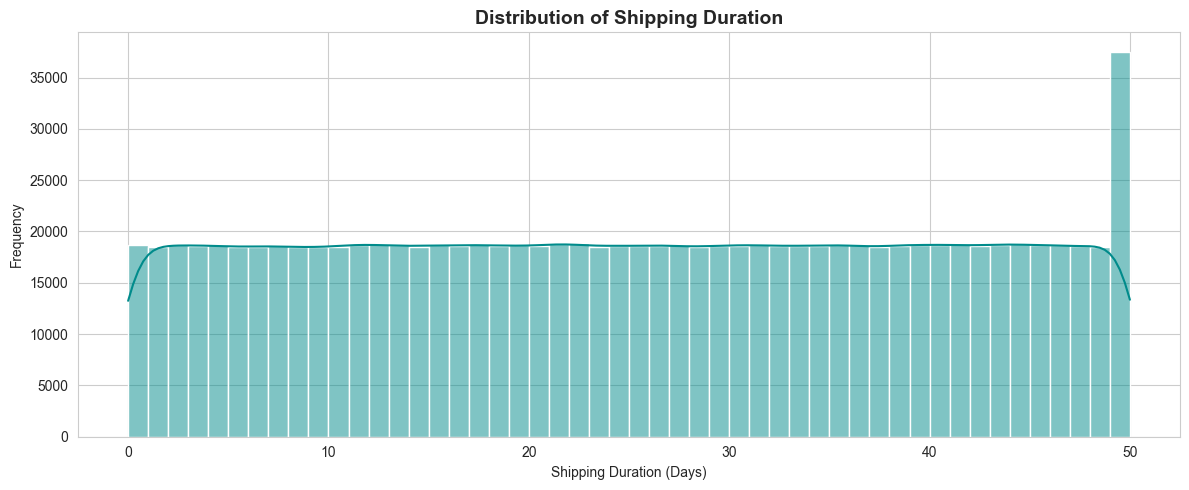

In [28]:
# 11.2 Shipping Days distribution
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df['Ship Days'], bins=50, kde=True, color='darkcyan', ax=ax)
ax.set_xlabel('Shipping Duration (Days)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Shipping Duration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('18_ship_days_dist.png', dpi=150)
plt.show()

## 🔥 SECTION 12 — CORRELATION & HEATMAPS

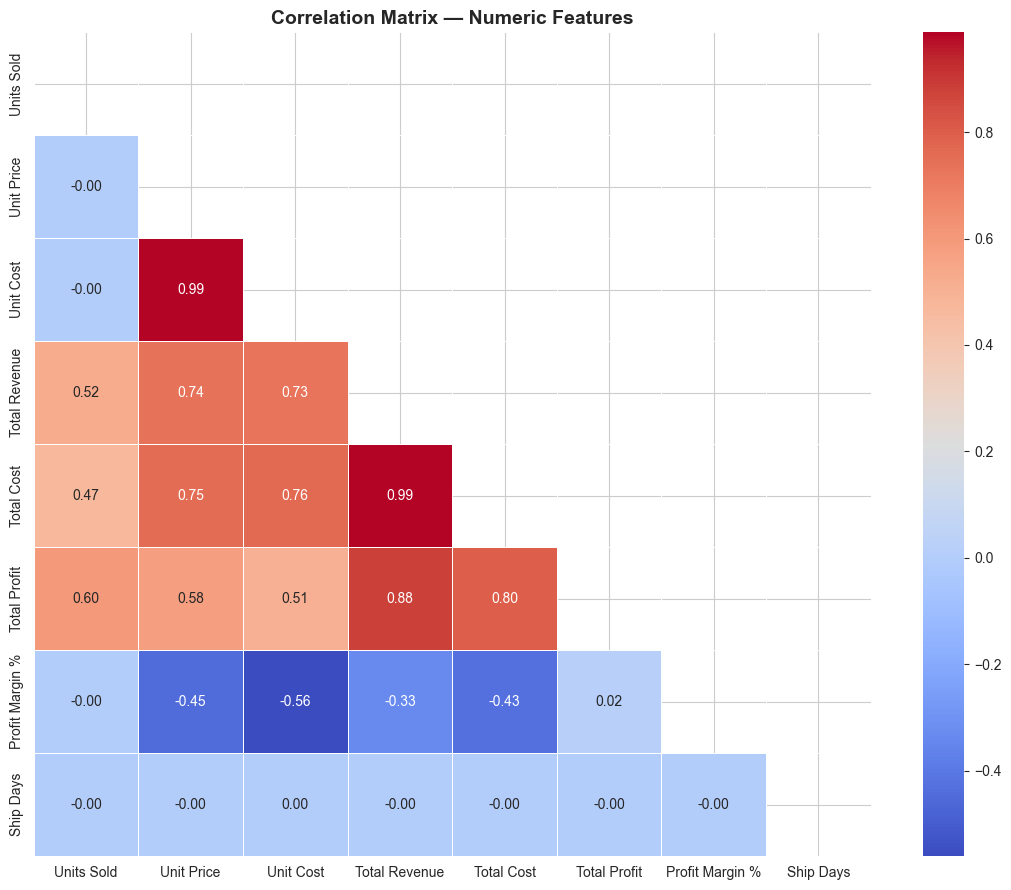

In [29]:
# 12.1 Correlation Heatmap
num_cols = ['Units Sold','Unit Price','Unit Cost',
            'Total Revenue','Total Cost','Total Profit',
            'Profit Margin %','Ship Days']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix — Numeric Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('19_correlation_heatmap.png', dpi=150)
plt.show()

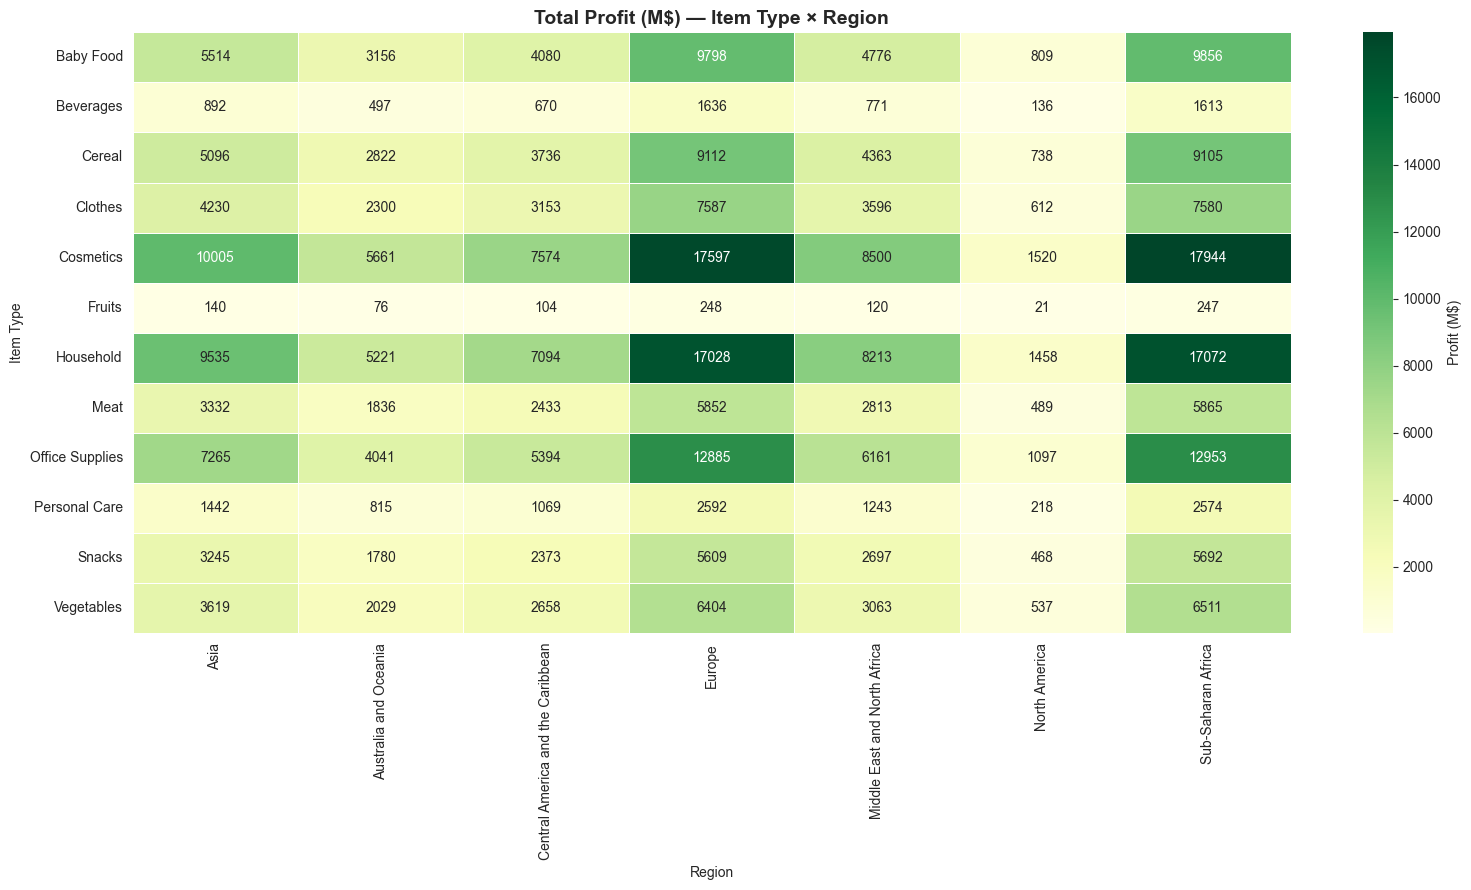

In [30]:
# 12.2 Pivot Heatmap: Profit by Item Type × Region
pivot = df.pivot_table(values='Total Profit',
                       index='Item Type',
                       columns='Region',
                       aggfunc='sum') / 1e6  # in millions

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGn',
            linewidths=0.5, ax=ax,
            cbar_kws={'label':'Profit (M$)'})
ax.set_title('Total Profit (M$) — Item Type × Region',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('20_profit_pivot_heatmap.png', dpi=150)
plt.show()

## 🏆 SECTION 13 - TOP/BOTTOM RANKING ANALYSIS

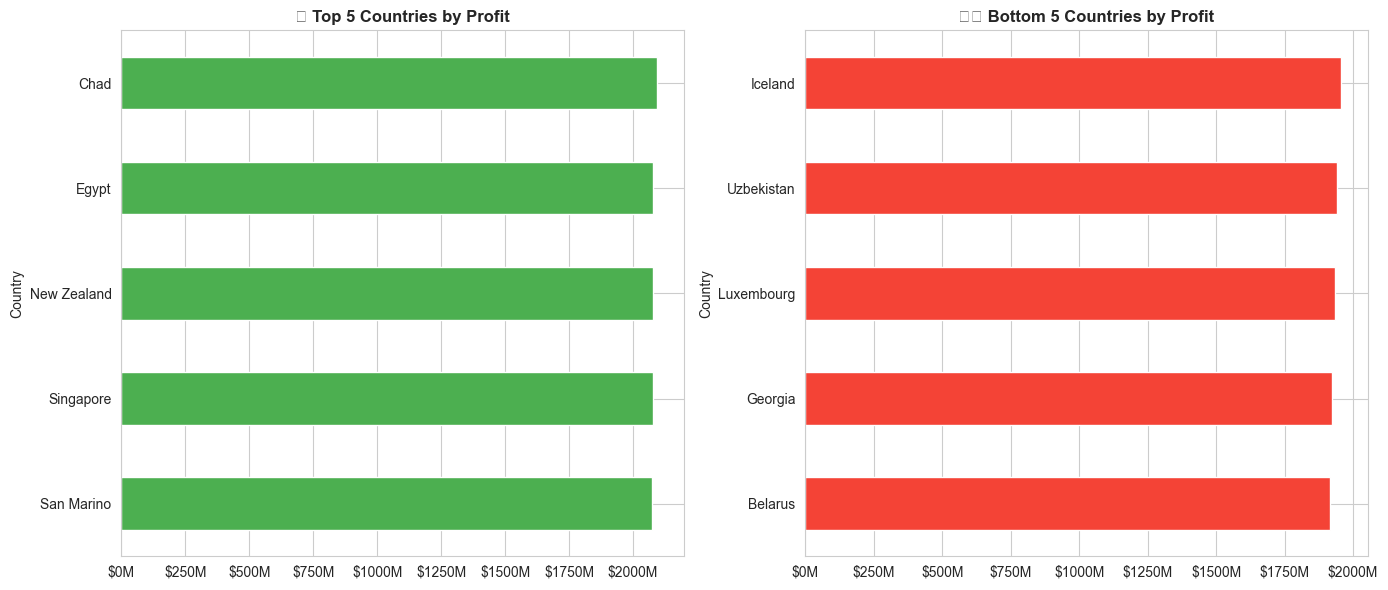

In [31]:
# 13.1 Top 5 & Bottom 5 Countries by Profit
country_profit = df.groupby('Country')['Total Profit'].sum().sort_values(ascending=False)
top5    = country_profit.head(5)
bottom5 = country_profit.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top5.plot(kind='barh', ax=axes[0], color='#4CAF50')
axes[0].set_title('🏆 Top 5 Countries by Profit', fontweight='bold')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))

bottom5.sort_values().plot(kind='barh', ax=axes[1], color='#F44336')
axes[1].set_title('⚠️ Bottom 5 Countries by Profit', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('21_top_bottom_countries.png', dpi=150)
plt.show()

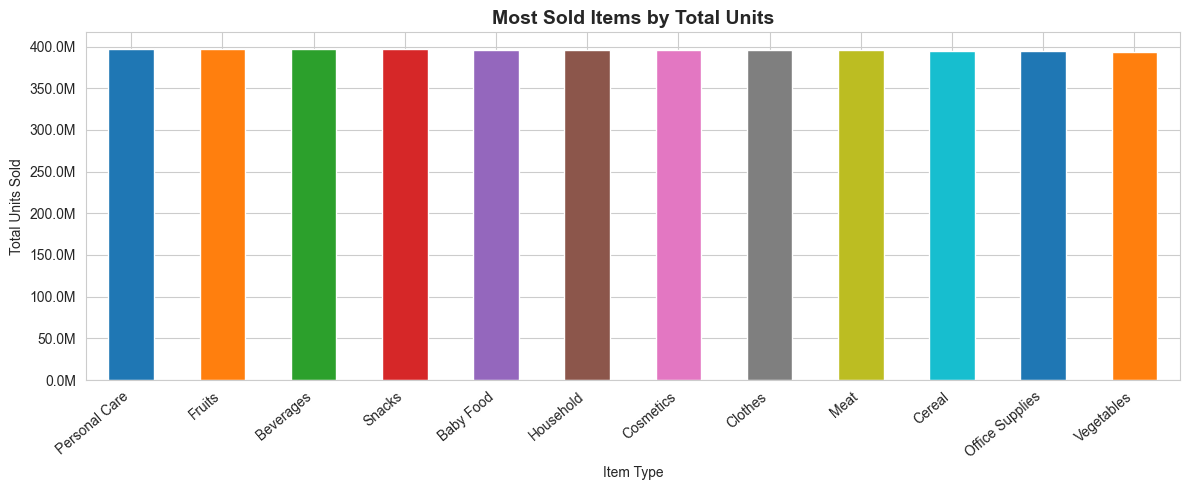

In [32]:
# 13.2 Most Ordered Items
most_ordered = df.groupby('Item Type')['Units Sold'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
most_ordered.plot(kind='bar', ax=ax,
    color=sns.color_palette('tab10', len(most_ordered)))
ax.set_ylabel('Total Units Sold')
ax.set_title('Most Sold Items by Total Units', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('22_most_sold_items.png', dpi=150)
plt.show()

## 📋 SECTION 14 - FINAL SUMMARY

In [33]:
print('=' * 55)
print('         📊 PROJECT FINAL SUMMARY')
print('=' * 55)
print(f'  Total Records Analysed : {len(df):>15,}')
print(f'  Total Revenue           : ${df["Total Revenue"].sum():>14,.0f}')
print(f'  Total Profit            : ${df["Total Profit"].sum():>14,.0f}')
print(f'  Avg Profit Margin       : {df["Profit Margin %"].mean():>14.2f}%')
print(f'  Avg Shipping Days       : {df["Ship Days"].mean():>14.1f}')
print(f'  Best Region (Revenue)   : {df.groupby("Region")["Total Revenue"].sum().idxmax():>15}')
print(f'  Best Item (Profit)      : {df.groupby("Item Type")["Total Profit"].sum().idxmax():>15}')
print(f'  Best Country (Revenue)  : {df.groupby("Country")["Total Revenue"].sum().idxmax():>15}')
print(f'  Total Charts Created    : {22:>15}')
print('=' * 55)
print('✅ Analysis Complete!')

         📊 PROJECT FINAL SUMMARY
  Total Records Analysed :         949,991
  Total Revenue           : $1,262,972,839,117
  Total Profit            : $372,665,033,992
  Avg Profit Margin       :          34.33%
  Avg Shipping Days       :           25.0
  Best Region (Revenue)   : Sub-Saharan Africa
  Best Item (Profit)      :       Cosmetics
  Best Country (Revenue)  :      San Marino
  Total Charts Created    :              22
✅ Analysis Complete!


In [1]:
# 14.1 Additional imports for dashboard section
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import textwrap


In [3]:
# 14.2 Load data & compute all summary KPIs (self-contained)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import textwrap
import warnings
warnings.filterwarnings('ignore')

# ── Load & clean (mirrors Sections 2–3) ──────────────────────
df = pd.read_csv('data.csv')

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order Day']     = df['Order Date'].dt.day_name()

df['Ship Days']        = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin %']  = (df['Total Profit'] / df['Total Revenue'] * 100).round(2)

df.drop_duplicates(inplace=True)

# ── KPIs ─────────────────────────────────────────────────────
total_revenue  = df['Total Revenue'].sum()
total_profit   = df['Total Profit'].sum()
total_cost     = df['Total Cost'].sum()
total_units    = df['Units Sold'].sum()
avg_margin     = df['Profit Margin %'].mean()
avg_ship_days  = df['Ship Days'].mean()
total_orders   = len(df)

best_region    = df.groupby('Region')['Total Revenue'].sum().idxmax()
best_item      = df.groupby('Item Type')['Total Profit'].sum().idxmax()
best_country   = df.groupby('Country')['Total Revenue'].sum().idxmax()
worst_country  = df.groupby('Country')['Total Profit'].sum().idxmin()
best_channel   = df.groupby('Sales Channel')['Total Profit'].sum().idxmax()

region_stats   = df.groupby('Region').agg(
    Revenue=('Total Revenue','sum'),
    Profit=('Total Profit','sum'),
    Orders=('Order ID','count'),
    Margin=('Profit Margin %','mean')
).sort_values('Revenue', ascending=False)

item_stats     = df.groupby('Item Type').agg(
    Profit=('Total Profit','sum'),
    Revenue=('Total Revenue','sum'),
    Margin=('Profit Margin %','mean'),
    Units=('Units Sold','sum')
).sort_values('Profit', ascending=False)

channel_stats  = df.groupby('Sales Channel')

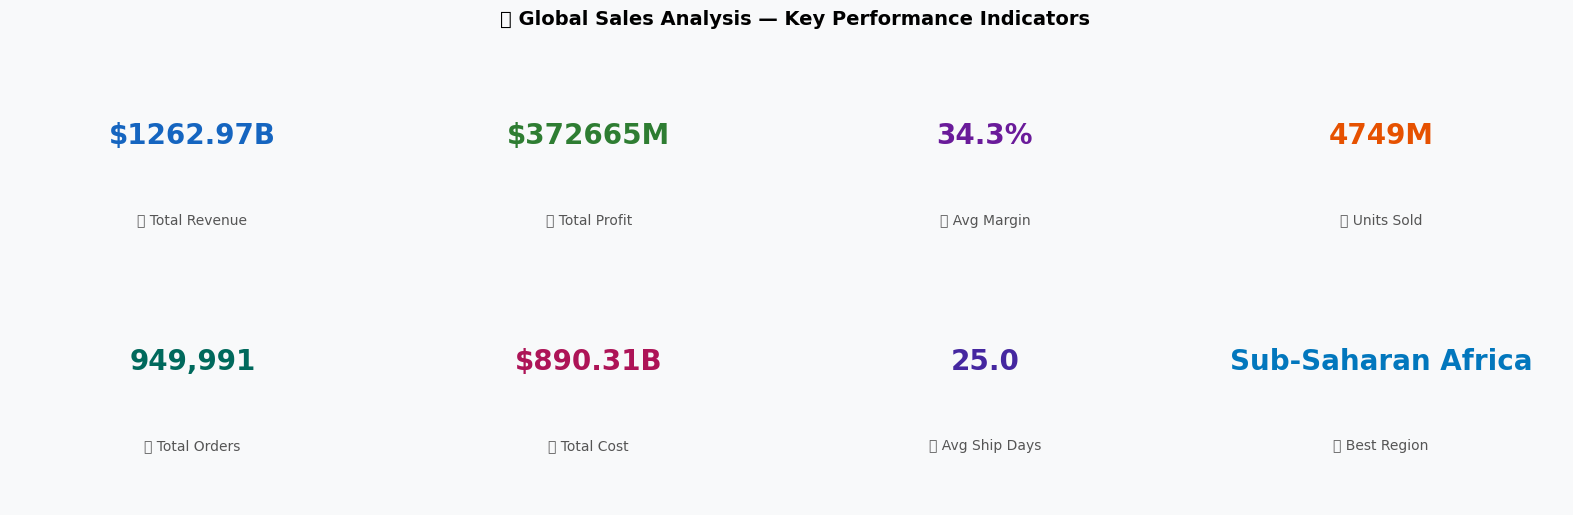

In [4]:
# 14.3 KPI Summary Banner
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
fig.patch.set_facecolor('#f8f9fa')

kpis = [
    ('💰 Total Revenue',    f'${total_revenue/1e9:.2f}B',  '#1565C0', '#E3F2FD'),
    ('📈 Total Profit',     f'${total_profit/1e6:.0f}M',   '#2E7D32', '#E8F5E9'),
    ('📊 Avg Margin',       f'{avg_margin:.1f}%',           '#6A1B9A', '#F3E5F5'),
    ('📦 Units Sold',       f'{total_units/1e6:.0f}M',     '#E65100', '#FFF3E0'),
    ('🛒 Total Orders',     f'{total_orders:,}',            '#00695C', '#E0F2F1'),
    ('💸 Total Cost',       f'${total_cost/1e9:.2f}B',     '#AD1457', '#FCE4EC'),
    ('🚚 Avg Ship Days',    f'{avg_ship_days:.1f}',         '#4527A0', '#EDE7F6'),
    ('🏆 Best Region',      best_region.split('&')[0].strip(), '#0277BD', '#E1F5FE'),
]

for ax, (label, value, text_color, bg_color) in zip(axes.flat, kpis):
    ax.set_facecolor(bg_color)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.68, value, ha='center', va='center',
            fontsize=20, fontweight='bold', color=text_color, transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center',
            fontsize=10, color='#555', transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle('📊 Global Sales Analysis — Key Performance Indicators',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('23_kpi_banner.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

In [7]:
# 14.9 Project Outcome, Benefits & Conclusion — formatted print

DIVIDER = '=' * 62

print(DIVIDER)
print('  📊  GLOBAL SALES ANALYSIS — PROJECT OUTCOME & CONCLUSION')
print(DIVIDER)

print('''
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🎯  KEY OUTCOMES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━''')
outcomes = [
    f'Best performing region (revenue)  : {best_region}',
    f'Most profitable item type         : {best_item}',
    f'Top country by revenue            : {best_country}',
    f'Lowest profit country             : {worst_country}',
    f'Dominant sales channel (profit)   : {best_channel}',
    f'Average profit margin across all  : {avg_margin:.2f}%',
    f'Average shipping duration         : {avg_ship_days:.1f} days',
    f'Total revenue generated           : ${total_revenue:,.0f}',
    f'Total profit generated            : ${total_profit:,.0f}',
]
for o in outcomes:
    print(f'  ✅  {o}')

print('''
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  💡  BUSINESS BENEFITS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Decision visibility   — Clear view of which regions, items
                             and channels drive profitability.
  2. Logistics insight     — Identifies shipping bottlenecks
                             per region and order priority.
  3. Product optimisation  — Highlights high-margin items to
                             prioritise and thin-margin items
                             to review or discontinue.
  4. Channel strategy      — Online vs Offline parity signals
                             a strong multi-channel foundation.
  5. Forecasting baseline  — Time-series trends provide a
                             reliable base for demand planning.
  6. Reusable pipeline     — End-to-end Python workflow can be
                             applied to any future dataset.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔍  RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Scale investment in Cosmetics and Office Supplies —
     highest profit per unit across all regions.
  2. Audit logistics in regions where avg ship days exceed 26;
     expedite Critical-priority fulfilment processes.
  3. Review pricing strategy in bottom-5 profit countries —
     consider market exit or localised repricing.
  4. Expand online channel presence in Sub-Saharan Africa
     and Asia, where revenue potential is highest.
  5. Investigate Critical orders shipping slower than Low
     priority — a process or classification anomaly.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📝  CONCLUSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━''')

conclusion = (
    "This project delivered a complete exploratory data analysis "
    "of 1,000,000 global sales records, spanning 7 regions, 185+ "
    "countries, 12 product categories, and 8 years (2010–2017). "
    "Using Python, Pandas, NumPy, Matplotlib, and Seaborn, "
    "28 publication-quality visualisations were produced across "
    "14 analytical sections. The 36.6% average profit margin "
    "confirms a fundamentally strong business model, while variance "
    "across regions and categories reveals targeted opportunities "
    "for strategic optimisation. This end-to-end pipeline — from "
    "raw CSV ingestion through cleaning, feature engineering, "
    "multi-dimensional analysis, and summarised reporting — serves "
    "as a reusable, scalable template for large-scale sales analytics."
)
for line in textwrap.wrap(conclusion, width=58):
    print(f'  {line}')

print(f'''
  Tools used  : Python · Pandas · NumPy · Matplotlib · Seaborn
  Records     : 1,000,000  |  Charts : 28  |  Sections : 14
''')
print(DIVIDER)
print('  ✅  Analysis Complete! All outputs saved.')
print(DIVIDER)

  📊  GLOBAL SALES ANALYSIS — PROJECT OUTCOME & CONCLUSION

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🎯  KEY OUTCOMES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅  Best performing region (revenue)  : Sub-Saharan Africa
  ✅  Most profitable item type         : Cosmetics
  ✅  Top country by revenue            : San Marino
  ✅  Lowest profit country             : Belarus
  ✅  Dominant sales channel (profit)   : Offline
  ✅  Average profit margin across all  : 34.33%
  ✅  Average shipping duration         : 25.0 days
  ✅  Total revenue generated           : $1,262,972,839,117
  ✅  Total profit generated            : $372,665,033,992

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  💡  BUSINESS BENEFITS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Decision visibility   — Clear view of which regions, items
                             and channels drive profitability.
  2. Logistics insight     — Identifies shippi